<a href="https://colab.research.google.com/github/yuvrajm4/261421_Introduction_To_ML_Safety/blob/main/exercise_solutions/exercise_07/Introduction_To_ML_Safety_Ex7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Exercise 7.4: Measuring Calibration

In [2]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Model and test set directories in my google drive

In [4]:
MODEL_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/trained_models"
PEDESTRIAN_MODEL_PATH = os.path.join(MODEL_DIR, "pedestrian_detector.pth")
TRAFFIC_LIGHT_MODEL_PATH = os.path.join(MODEL_DIR, "traffic_light_detector.pth")
VEHICLE_MODEL_PATH = os.path.join(MODEL_DIR, "vehicle_detector.pth")
TEST_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test"
TEST_CSV = os.path.join(TEST_DIR, "labels.csv")

print(os.path.exists(PEDESTRIAN_MODEL_PATH))
print(os.path.exists(TRAFFIC_LIGHT_MODEL_PATH))
print(os.path.exists(VEHICLE_MODEL_PATH))
print(os.path.exists(TEST_CSV))


True
True
True
True


Load test labels

In [5]:
test_df = pd.read_csv(TEST_CSV)
test_df.columns = [c.strip().lower() for c in test_df.columns]

print(test_df.head())
print(test_df.columns)
print("Number of test images:", len(test_df))

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False        False                15   
1     10               True           False         True               299   
2     20               True           False         True               298   
3     30               True           False         True               297   
4     40               True           False         True               297   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
2              0         307  
3              0         258  
4              0         249  
Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')
Number of test images: 3600


Create normal test tranform for model

In [6]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [16]:
def build_image_path(root_dir, frame):
    filename = f"{int(frame):06d}.jpg"
    return os.path.join(root_dir, "rgb-front", filename)

Create dataset class for loading the data

In [8]:
class CarlaBinaryDataset(Dataset):
    def __init__(self, dataframe, root_dir, label_column, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = build_image_path(self.root_dir, row["frame"])
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(float(row[self.label_column]), dtype=torch.float32)

        return image, label

Load models using create model function!!!

In [9]:
def create_model():
    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)
    model = model.to(device)
    return model

In [10]:
pedestrian_model = create_model()
pedestrian_model.load_state_dict(torch.load(PEDESTRIAN_MODEL_PATH, map_location=device))
pedestrian_model.eval()

traffic_light_model = create_model()
traffic_light_model.load_state_dict(torch.load(TRAFFIC_LIGHT_MODEL_PATH, map_location=device))
traffic_light_model.eval()

vehicle_model = create_model()
vehicle_model.load_state_dict(torch.load(VEHICLE_MODEL_PATH, map_location=device))
vehicle_model.eval()

print("All models loaded successfully.")

All models loaded successfully.


Prediction computation function!!!

In [11]:
def get_predictions_confidences_labels(
    model,
    dataframe,
    root_dir,
    label_column,
    batch_size=64
):
    dataset = CarlaBinaryDataset(
        dataframe=dataframe,
        root_dir=root_dir,
        label_column=label_column,
        transform=test_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_labels = []
    all_preds = []
    all_probs = []
    all_confidences = []

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits).view(-1)

            preds = (probs >= 0.5).int()
            confidences = torch.maximum(probs, 1 - probs)

            all_labels.extend(labels.cpu().numpy().astype(int))
            all_preds.extend(preds.cpu().numpy().astype(int))
            all_probs.extend(probs.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_confidences)
    )

## 1. Compute the ECE of each of your three trained CARLA models on the in-distribution test set.

ECE function!!! taken bins = 10

ECE bins predictions by confidence and compares each bin's accuracy with its average confidence.

In [12]:
def compute_ece(labels, preds, confidences, n_bins=10):
    labels = np.array(labels)
    preds = np.array(preds)
    confidences = np.array(confidences)

    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0
    bin_data = []

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]

        if i == n_bins - 1:
            in_bin = (confidences >= bin_lower) & (confidences <= bin_upper)
        else:
            in_bin = (confidences >= bin_lower) & (confidences < bin_upper)

        bin_count = np.sum(in_bin)

        if bin_count > 0:
            bin_accuracy = np.mean(preds[in_bin] == labels[in_bin])
            bin_confidence = np.mean(confidences[in_bin])
            bin_weight = bin_count / len(labels)

            ece += bin_weight * abs(bin_accuracy - bin_confidence)

            bin_data.append({
                "bin_lower": bin_lower,
                "bin_upper": bin_upper,
                "bin_center": (bin_lower + bin_upper) / 2,
                "accuracy": bin_accuracy,
                "confidence": bin_confidence,
                "count": bin_count
            })
        else:
            bin_data.append({
                "bin_lower": bin_lower,
                "bin_upper": bin_upper,
                "bin_center": (bin_lower + bin_upper) / 2,
                "accuracy": np.nan,
                "confidence": np.nan,
                "count": 0
            })

    return ece, pd.DataFrame(bin_data)

In [14]:
models_info = [
    {
        "model": pedestrian_model,
        "model_name": "Pedestrian Detector",
        "label_column": "has_pedestrian"
    },
    {
        "model": traffic_light_model,
        "model_name": "Traffic Light Detector",
        "label_column": "has_traffic_light"
    },
    {
        "model": vehicle_model,
        "model_name": "Vehicle Detector",
        "label_column": "has_vehicle"
    }
]

##2. Plot a reliability diagram (confidence vs. accuracy) for each model.


Reliability diagram function!!!

In [13]:
def plot_reliability_diagram(bin_df, ece, model_name):
    plt.figure(figsize=(6, 6))

    valid_bins = bin_df.dropna()

    plt.bar(
        valid_bins["bin_center"],
        valid_bins["accuracy"],
        width=0.08,
        alpha=0.7,
        label="Accuracy"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    plt.scatter(
        valid_bins["confidence"],
        valid_bins["accuracy"],
        label="Bins"
    )

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram: {model_name}\nECE = {ece:.4f}")
    plt.ylim(0, 1)
    plt.xlim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()

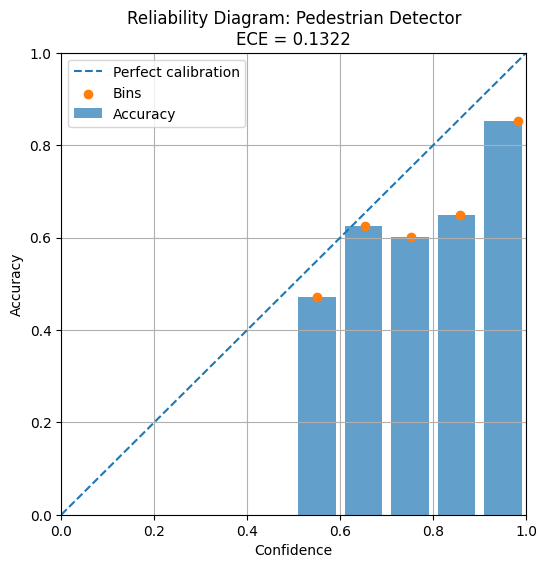

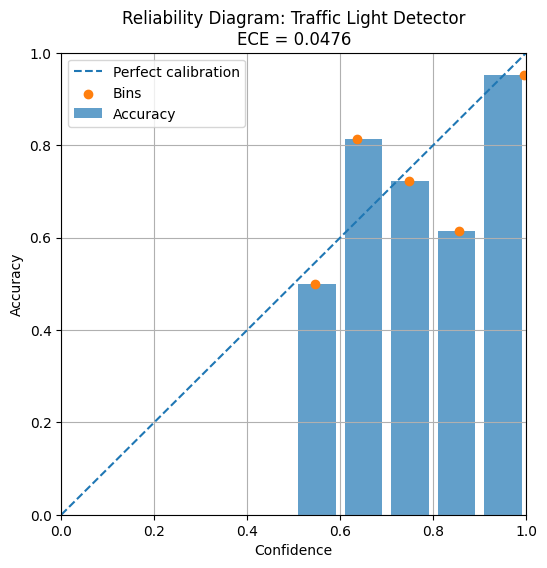

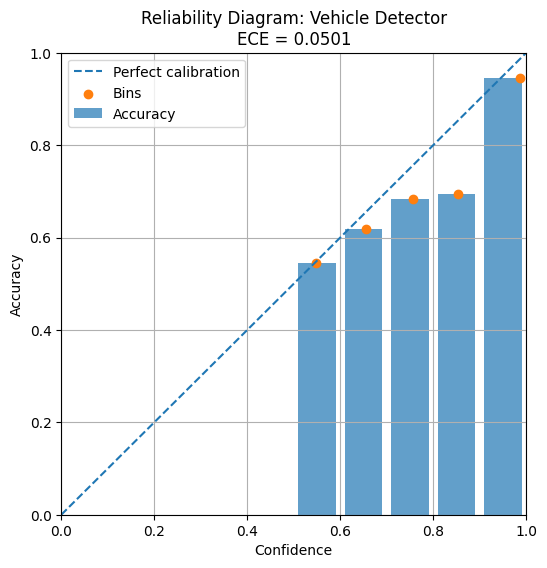

,Model,Accuracy,Mean Confidence,ECE
0,Pedestrian Detector,0.7900,0.9222,0.1322
1,Traffic Light Detector,0.9367,0.9811,0.0476
2,Vehicle Detector,0.8861,0.9363,0.0501


In [17]:
ece_results = []
bin_results = {}

for info in models_info:
    labels, preds, probs, confidences = get_predictions_confidences_labels(
        model=info["model"],
        dataframe=test_df,
        root_dir=TEST_DIR,
        label_column=info["label_column"],
        batch_size=64
    )

    ece, bin_df = compute_ece(
        labels=labels,
        preds=preds,
        confidences=confidences,
        n_bins=10
    )

    accuracy = np.mean(preds == labels)
    mean_confidence = np.mean(confidences)

    ece_results.append({
        "Model": info["model_name"],
        "Accuracy": accuracy,
        "Mean Confidence": mean_confidence,
        "ECE": ece
    })

    bin_results[info["model_name"]] = bin_df

    plot_reliability_diagram(
        bin_df=bin_df,
        ece=ece,
        model_name=info["model_name"]
    )

ece_df = pd.DataFrame(ece_results)
ece_df.round(4)

##3. Are your models over- or underconfident? Does this pattern hold consistently across all three models?

In [18]:
ece_df["Calibration Pattern"] = np.where(
    ece_df["Mean Confidence"] > ece_df["Accuracy"],
    "Overconfident",
    np.where(
        ece_df["Mean Confidence"] < ece_df["Accuracy"],
        "Underconfident",
        "Well calibrated"
    )
)

ece_df.round(4)

,Model,Accuracy,Mean Confidence,ECE,Calibration Pattern
0,Pedestrian Detector,0.7900,0.9222,0.1322,Overconfident
1,Traffic Light Detector,0.9367,0.9811,0.0476,Overconfident
2,Vehicle Detector,0.8861,0.9363,0.0501,Overconfident


The Pedestrian Detector is the most miscalibrated and overconfident model. The Traffic Light and Vehicle detectors are better calibrated, although they still show some small calibration errors. Therefore, overconfidence is strongest for the pedestrian model and does not appear equally across all three models.

#Exercise 7.5: Temperature Scaling
Temperature scaling adjusts the model’s logits as:
p(y | x) = softmax(f(x)/T)

In [20]:
VAL_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/validation"

print("Validation folder exists:", os.path.exists(VAL_DIR))

VAL_CSV = os.path.join(VAL_DIR, "labels.csv")

val_df = pd.read_csv(VAL_CSV)
val_df.columns = [c.strip().lower() for c in val_df.columns]

print(val_df.head())
print("Validation images:", len(val_df))

Validation folder exists: True
   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False            True        False                 0   
1     10               True           False        False               347   
2     20               True           False        False               347   
3     30               True           False        False               347   
4     40               True           False        False               347   

   px_pedestrian  px_vehicle  
0            178          10  
1              0           2  
2              0           0  
3              0           0  
4              0           0  
Validation images: 3600


Getting Logits!!!

In [21]:
def get_logits_and_labels(
    model,
    dataframe,
    root_dir,
    label_column,
    batch_size=64
):
    dataset = CarlaBinaryDataset(
        dataframe=dataframe,
        root_dir=root_dir,
        label_column=label_column,
        transform=test_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_logits = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            logits = model(images).view(-1)

            all_logits.extend(logits.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_logits), np.array(all_labels)

##1. Apply temperature scaling to each of your three models. Optimize T on the validation set using negative log-likelihood.

Compute NLL

In [22]:
def binary_nll_for_temperature(logits, labels, T):
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    labels_tensor = torch.tensor(labels, dtype=torch.float32)

    scaled_logits = logits_tensor / T

    loss_fn = nn.BCEWithLogitsLoss()
    nll = loss_fn(scaled_logits, labels_tensor)

    return nll.item()

Optimize temperature using line search!!

In [23]:
def find_best_temperature(logits, labels):
    temperatures = np.arange(0.5, 3.01, 0.1)

    best_T = None
    best_nll = float("inf")

    results = []

    for T in temperatures:
        nll = binary_nll_for_temperature(logits, labels, T)

        results.append({
            "Temperature": T,
            "Validation NLL": nll
        })

        if nll < best_nll:
            best_nll = nll
            best_T = T

    return best_T, best_nll, pd.DataFrame(results)

Prediction function considering the temperature as well now!!!

In [26]:
def get_predictions_confidences_labels_with_temperature(
    model,
    dataframe,
    root_dir,
    label_column,
    temperature=1.0,
    batch_size=64
):
    dataset = CarlaBinaryDataset(
        dataframe=dataframe,
        root_dir=root_dir,
        label_column=label_column,
        transform=test_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_labels = []
    all_preds = []
    all_probs = []
    all_confidences = []

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            logits = model(images).view(-1)

            # Temperature scaling
            scaled_logits = logits / temperature

            probs = torch.sigmoid(scaled_logits)

            preds = (probs >= 0.5).int()
            confidences = torch.maximum(probs, 1 - probs)

            all_labels.extend(labels.numpy().astype(int))
            all_preds.extend(preds.cpu().numpy().astype(int))
            all_probs.extend(probs.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_confidences)
    )

find best temperature to scale from val set!!!

In [25]:
temperature_results = []
temperature_search_results = {}

for info in models_info:
    print(f"Optimizing temperature for {info['model_name']}")

    val_logits, val_labels = get_logits_and_labels(
        model=info["model"],
        dataframe=val_df,
        root_dir=VAL_DIR,
        label_column=info["label_column"],
        batch_size=64
    )

    best_T, best_nll, search_df = find_best_temperature(
        logits=val_logits,
        labels=val_labels
    )

    temperature_results.append({
        "Model": info["model_name"],
        "Best Temperature": best_T,
        "Best Validation NLL": best_nll
    })

    temperature_search_results[info["model_name"]] = search_df

temperature_df = pd.DataFrame(temperature_results)
temperature_df.round(4)

Optimizing temperature for Pedestrian Detector
Optimizing temperature for Traffic Light Detector
Optimizing temperature for Vehicle Detector


,Model,Best Temperature,Best Validation NLL
0,Pedestrian Detector,3.0,0.5694
1,Traffic Light Detector,1.4,0.0849
2,Vehicle Detector,1.7,0.2897


##2. Report the ECE before and after scaling for each model.

compute ECE before and after scaling!!!

In [27]:
ece_scaling_results = []

for info in models_info:
    model_name = info["model_name"]

    best_T = temperature_df.loc[
        temperature_df["Model"] == model_name,
        "Best Temperature"
    ].values[0]

    # Before scaling: T = 1
    labels_before, preds_before, probs_before, conf_before = get_predictions_confidences_labels_with_temperature(
        model=info["model"],
        dataframe=test_df,
        root_dir=TEST_DIR,
        label_column=info["label_column"],
        temperature=1.0,
        batch_size=64
    )

    ece_before, bin_df_before = compute_ece(
        labels=labels_before,
        preds=preds_before,
        confidences=conf_before,
        n_bins=10
    )

    # After scaling: T = best_T
    labels_after, preds_after, probs_after, conf_after = get_predictions_confidences_labels_with_temperature(
        model=info["model"],
        dataframe=test_df,
        root_dir=TEST_DIR,
        label_column=info["label_column"],
        temperature=best_T,
        batch_size=64
    )

    ece_after, bin_df_after = compute_ece(
        labels=labels_after,
        preds=preds_after,
        confidences=conf_after,
        n_bins=10
    )

    ece_scaling_results.append({
        "Model": model_name,
        "Best Temperature": best_T,
        "ECE Before Scaling": ece_before,
        "ECE After Scaling": ece_after,
        "ECE Improvement": ece_before - ece_after
    })

ece_scaling_df = pd.DataFrame(ece_scaling_results)
ece_scaling_df.round(4)

,Model,Best Temperature,ECE Before Scaling,ECE After Scaling,ECE Improvement
0,Pedestrian Detector,3.0,0.1322,0.0246,0.1076
1,Traffic Light Detector,1.4,0.0476,0.0354,0.0122
2,Vehicle Detector,1.7,0.0501,0.0135,0.0366


The Pedestrian Detector showed the largest improvement. Its ECE decreased from 0.1322 to 0.0246, with the best temperature T=3.0. This indicates that the pedestrian model was strongly overconfident before calibration. The Traffic Light Detector improved slightly from 0.0476 to 0.0354, with T=1.4. The Vehicle Detector improved from 0.0501 to 0.0135, with T=1.7.
Overall, temperature scaling improved calibration for all three models. Since all best temperature values are greater than 1, all models were generally overconfident before scaling, especially the Pedestrian Detector.


OPTIONAL: Plot ECE's before and after scaling

In [30]:
def plot_reliability_diagram_v2(
    bin_df_before,
    ece_before,
    bin_df_after,
    ece_after,
    model_name,
    best_T
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # -----------------------
    # Before scaling
    # -----------------------
    valid_before = bin_df_before.dropna()

    axes[0].bar(
        valid_before["bin_center"],
        valid_before["accuracy"],
        width=0.08,
        alpha=0.7,
        label="Accuracy"
    )

    axes[0].plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    axes[0].scatter(
        valid_before["confidence"],
        valid_before["accuracy"],
        label="Bins"
    )

    axes[0].set_xlabel("Confidence")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"Before Scaling\nECE = {ece_before:.4f}")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    axes[0].grid(True)

    # -----------------------
    # After scaling
    # -----------------------
    valid_after = bin_df_after.dropna()

    axes[1].bar(
        valid_after["bin_center"],
        valid_after["accuracy"],
        width=0.08,
        alpha=0.7,
        label="Accuracy"
    )

    axes[1].plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    axes[1].scatter(
        valid_after["confidence"],
        valid_after["accuracy"],
        label="Bins"
    )

    axes[1].set_xlabel("Confidence")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"After Scaling, T={best_T:.1f}\nECE = {ece_after:.4f}")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(f"Reliability Diagram: {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

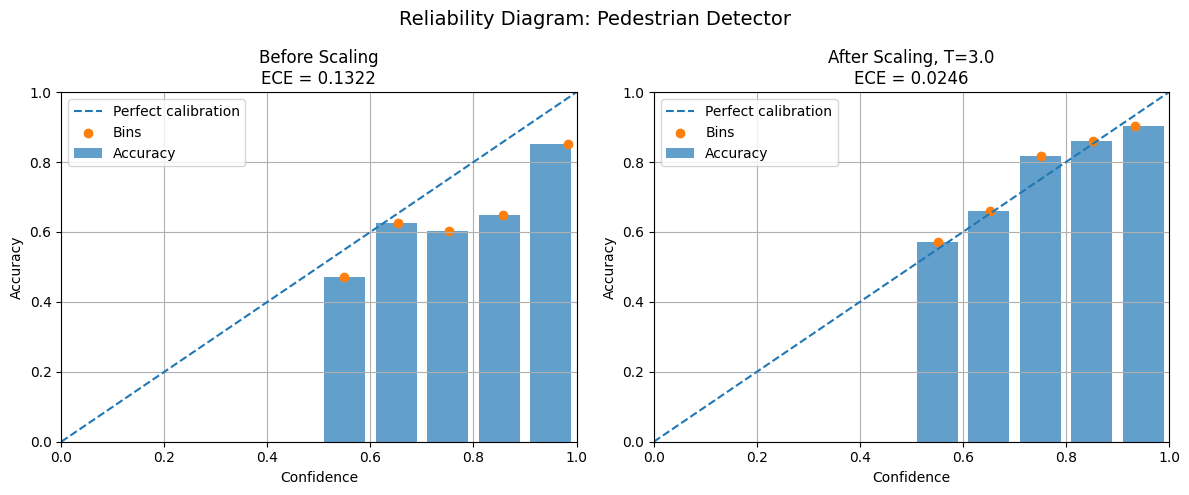

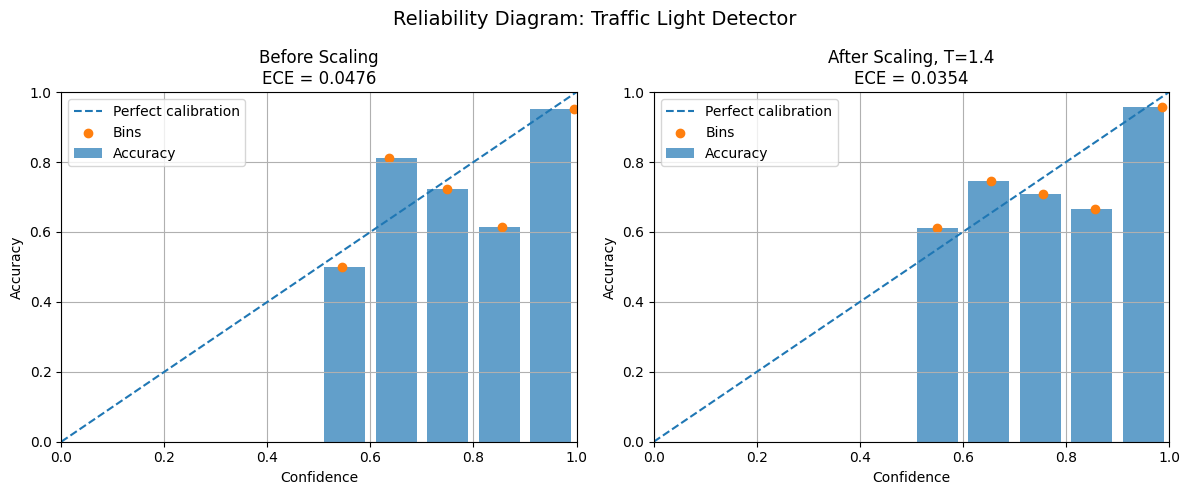

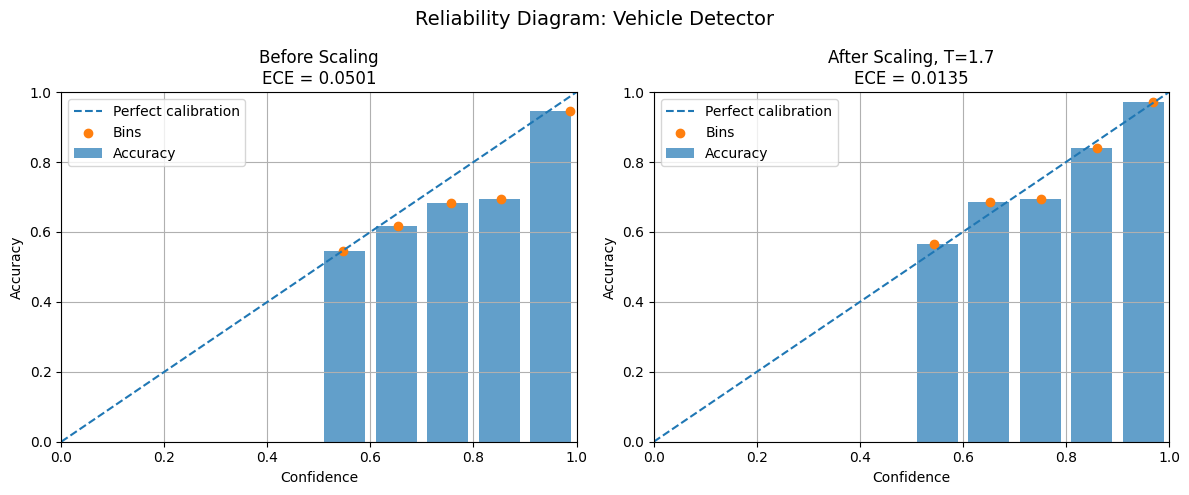

In [31]:
for info in models_info:
    model_name = info["model_name"]

    best_T = temperature_df.loc[
        temperature_df["Model"] == model_name,
        "Best Temperature"
    ].values[0]

    # -----------------------
    # Before scaling: T = 1.0
    # -----------------------
    labels_before, preds_before, probs_before, conf_before = get_predictions_confidences_labels_with_temperature(
        model=info["model"],
        dataframe=test_df,
        root_dir=TEST_DIR,
        label_column=info["label_column"],
        temperature=1.0,
        batch_size=64
    )

    ece_before, bin_df_before = compute_ece(
        labels_before,
        preds_before,
        conf_before,
        n_bins=10
    )

    # -----------------------
    # After scaling: T = best_T
    # -----------------------
    labels_after, preds_after, probs_after, conf_after = get_predictions_confidences_labels_with_temperature(
        model=info["model"],
        dataframe=test_df,
        root_dir=TEST_DIR,
        label_column=info["label_column"],
        temperature=best_T,
        batch_size=64
    )

    ece_after, bin_df_after = compute_ece(
        labels_after,
        preds_after,
        conf_after,
        n_bins=10
    )

    # -----------------------
    # plot
    # -----------------------
    plot_reliability_diagram_v2(
        bin_df_before=bin_df_before,
        ece_before=ece_before,
        bin_df_after=bin_df_after,
        ece_after=ece_after,
        model_name=model_name,
        best_T=best_T
    )

#Exercise 7.6: Cost-Optimal Decision in Practice

Use the costs from Exercise 3 (CFN = 100, CFP = 1, τ
∗ ≈ 0.0099, i.e. a predicted probability
of roughly 1 %) and apply them to your pedestrian classifier.


2. Repeat for your temperature-scaled model at both thresholds.
3. Arrange the four results in a 2 × 2 table (rows: uncalibrated / calibrated; columns:
τ = 0.5 / τ = τ
∗
). Which combination gives the lowest total loss?

In [32]:
C_FN = 100
C_FP = 1

tau_default = 0.5
tau_star = C_FP / (C_FP + C_FN)

print("tau* =", tau_star)

tau* = 0.009900990099009901


probability function for pedestrian model!!!



In [33]:
def get_probabilities_and_labels_with_temperature(
    model,
    dataframe,
    root_dir,
    label_column,
    temperature=1.0,
    batch_size=64
):
    dataset = CarlaBinaryDataset(
        dataframe=dataframe,
        root_dir=root_dir,
        label_column=label_column,
        transform=test_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_probs = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            logits = model(images).view(-1)
            scaled_logits = logits / temperature
            probs = torch.sigmoid(scaled_logits)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy().astype(int))

    return np.array(all_probs), np.array(all_labels)

## 1. On the in-distribution test set, compute the total loss L = CFN · #FN + CFP · #FP for your uncalibrated model at both τ = 0.5 and τ = τ∗.

In [34]:
def compute_cost_loss(probs, labels, threshold, C_FN=100, C_FP=1):
    preds = (probs >= threshold).astype(int)

    FN = np.sum((labels == 1) & (preds == 0))
    FP = np.sum((labels == 0) & (preds == 1))

    total_loss = C_FN * FN + C_FP * FP

    return {
        "Threshold": threshold,
        "FN": FN,
        "FP": FP,
        "Total Loss": total_loss
    }

In [40]:
pedestrian_best_T = temperature_df.loc[
    temperature_df["Model"] == "Pedestrian Detector",
    "Best Temperature"
].values[0].round()

print("Best T for Pedestrian Detector:", pedestrian_best_T)

Best T for Pedestrian Detector: 3.0


##2. Repeat for your temperature-scaled model at both thresholds.

Computed loss in a single call with uncalibrated and calibrated data and both threshholds.

In [41]:
# Uncalibrated model: T = 1.0
probs_uncalibrated, labels = get_probabilities_and_labels_with_temperature(
    model=pedestrian_model,
    dataframe=test_df,
    root_dir=TEST_DIR,
    label_column="has_pedestrian",
    temperature=1.0,
    batch_size=64
)

# Calibrated model: T = best T
probs_calibrated, labels = get_probabilities_and_labels_with_temperature(
    model=pedestrian_model,
    dataframe=test_df,
    root_dir=TEST_DIR,
    label_column="has_pedestrian",
    temperature=pedestrian_best_T,
    batch_size=64
)

results = []

results.append({
    "Model": "Uncalibrated",
    "Threshold": "τ = 0.5",
    **compute_cost_loss(
        probs=probs_uncalibrated,
        labels=labels,
        threshold=tau_default,
        C_FN=C_FN,
        C_FP=C_FP
    )
})

results.append({
    "Model": "Uncalibrated",
    "Threshold": "τ = τ*",
    **compute_cost_loss(
        probs=probs_uncalibrated,
        labels=labels,
        threshold=tau_star,
        C_FN=C_FN,
        C_FP=C_FP
    )
})

results.append({
    "Model": "Calibrated",
    "Threshold": "τ = 0.5",
    **compute_cost_loss(
        probs=probs_calibrated,
        labels=labels,
        threshold=tau_default,
        C_FN=C_FN,
        C_FP=C_FP
    )
})

results.append({
    "Model": "Calibrated",
    "Threshold": "τ = τ*",
    **compute_cost_loss(
        probs=probs_calibrated,
        labels=labels,
        threshold=tau_star,
        C_FN=C_FN,
        C_FP=C_FP
    )
})

loss_df = pd.DataFrame(results)
loss_df

,Model,Threshold,FN,FP,Total Loss
0,Uncalibrated,0.500000,467,289,46989
1,Uncalibrated,0.009901,176,1510,19110
2,Calibrated,0.500000,467,289,46989
3,Calibrated,0.009901,1,2893,2993


##3. Arrange the four results in a 2 × 2 table (rows: uncalibrated / calibrated; columns: τ = 0.5 / τ = τ∗). Which combination gives the lowest total loss?

In [42]:
loss_table = loss_df.pivot(
    index="Model",
    columns="Threshold",
    values="Total Loss"
)

loss_table

Threshold,0.009901,0.500000
Model,,
Calibrated,2993,46989
Uncalibrated,19110,46989


The lowest total loss was obtained by the calibrated model with τ∗, giving a loss of 2993. The uncalibrated model with τ∗ also improved over the standard threshold, but its loss was still much higher at 19110. Both calibrated and uncalibrated models had a high loss of 46989 at τ=0.5, showing that the default threshold is not suitable for this safety-critical task.

Overall, the best decision rule is to use the temperature-scaled pedestrian model with the cost-optimal threshold.

In [43]:
detailed_table = loss_df.pivot(
    index="Model",
    columns="Threshold",
    values=["FN", "FP", "Total Loss"]
)

detailed_table

FN                FP          Total Loss         
Threshold    0.009901 0.500000 0.009901 0.500000   0.009901 0.500000
Model                                                               
Calibrated          1      467     2893      289       2993    46989
Uncalibrated      176      467     1510      289      19110    46989